In [4]:
from fastai.vision.all import *

In [6]:
from pathlib import Path

path = Path("../data")

print(path)

..\data


In [7]:
print([p.name for p in path.iterdir() if p.is_dir()])

['Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'models', 'Northern_Corn_Leaf_Blight']


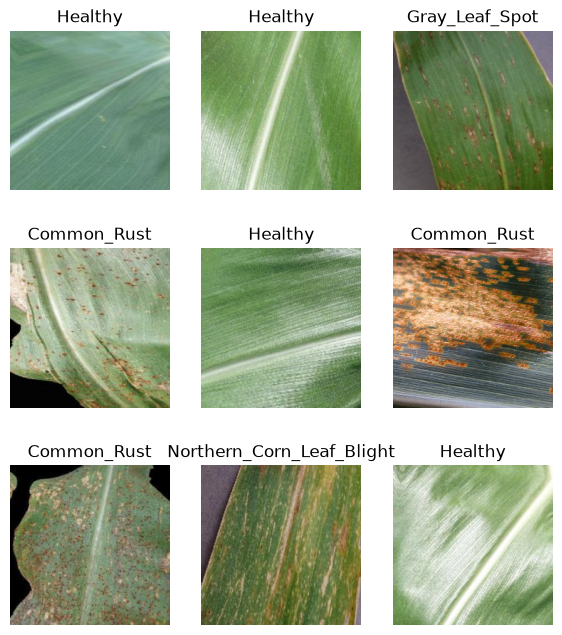

In [16]:
dls = ImageDataLoaders.from_folder(
    path,
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(
        size=224,
        min_scale=0.75,
        max_rotate=15,
        max_zoom=1.1,
        max_lighting=0.2,
        max_warp=0.1,
        p_affine=0.75,
        p_lighting=0.75
    ),
    bs=32
)
dls.show_batch(max_n=9, figsize=(7, 8))

In [9]:
learn = vision_learner(
    dls,
    efficientnet_b0,
    metrics=accuracy
)

c:\Users\ssult\dl-env\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ssult\dl-env\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<div></div>

SuggestedLRs(valley=0.0020892962347716093)

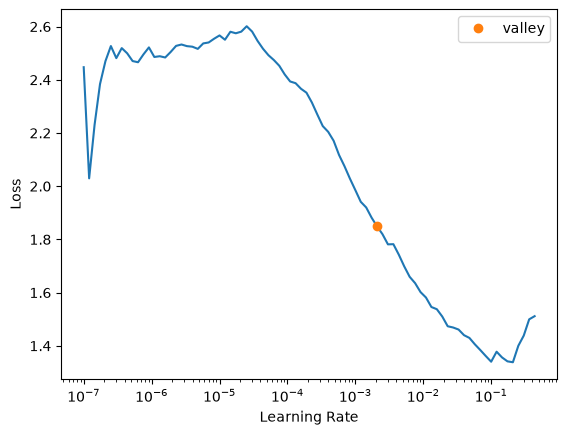

In [8]:
learn.lr_find()

In [9]:
from fastai.callback.tracker import SaveModelCallback

save_best = SaveModelCallback(
    monitor='valid_loss',
    fname='best_maize_model'
)

learn.fine_tune(
    10,
    base_lr=0.002,
    cbs=save_best
)

epoch,train_loss,valid_loss,accuracy,time
0,0.626772,0.366991,0.896057,00:27


Better model found at epoch 0 with valid_loss value: 0.3669908344745636.


epoch,train_loss,valid_loss,accuracy,time
0,0.380992,0.259027,0.909200,00:29
1,0.292590,0.225350,0.918757,00:31
2,0.285715,0.216409,0.918757,00:30
3,0.228077,0.196760,0.921147,00:30
4,0.219806,0.192266,0.929510,00:30
5,0.202646,0.164342,0.936679,00:30
6,0.174105,0.182166,0.936679,00:30
7,0.152824,0.150168,0.946237,00:30
8,0.152801,0.153468,0.946237,00:30
9,0.120423,0.155972,0.943847,00:31


Better model found at epoch 0 with valid_loss value: 0.2590266466140747.
Better model found at epoch 1 with valid_loss value: 0.22535017132759094.
Better model found at epoch 2 with valid_loss value: 0.2164091020822525.
Better model found at epoch 3 with valid_loss value: 0.19676047563552856.
Better model found at epoch 4 with valid_loss value: 0.19226635992527008.
Better model found at epoch 5 with valid_loss value: 0.1643419712781906.
Better model found at epoch 7 with valid_loss value: 0.15016841888427734.


In [10]:
print("Learner path:", learn.path)
print("Model directory:", learn.model_dir)

Learner path: ..\data
Model directory: models


In [11]:
from pathlib import Path

print(list(Path(learn.path).rglob("best_maize_model*")))

[Path('../data/models/best_maize_model.pth')]


In [12]:
learn.load('best_maize_model')

c:\Users\ssult\dl-env\.venv\Lib\site-packages\fastai\learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


In [13]:
learn.validate()


[0.15016841888427734, 0.9462365508079529]

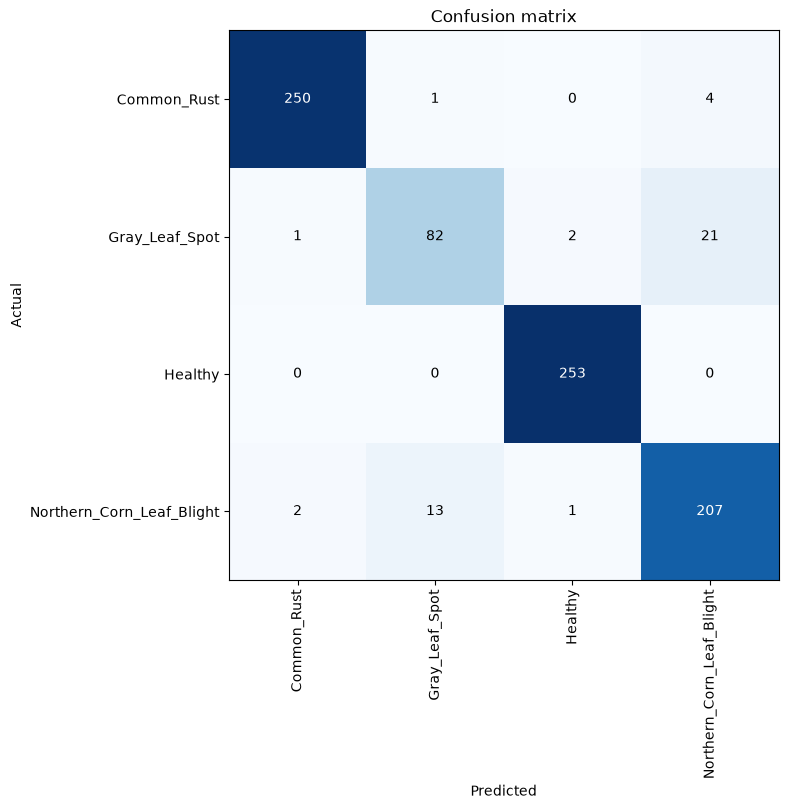

In [14]:
interp = ClassificationInterpretation.from_learner(learn)

interp.plot_confusion_matrix(figsize=(8, 8))

In [15]:
interp.print_classification_report()


                           precision    recall  f1-score   support

              Common_Rust       0.99      0.98      0.98       255
           Gray_Leaf_Spot       0.85      0.77      0.81       106
                  Healthy       0.99      1.00      0.99       253
Northern_Corn_Leaf_Blight       0.89      0.93      0.91       223

                 accuracy                           0.95       837
                macro avg       0.93      0.92      0.93       837
             weighted avg       0.95      0.95      0.95       837



In [18]:
pred_class, pred_idx, probs = learn.predict(dls.valid.items[0])

print("Predicted class:", pred_class)
print("Class probabilities:", probs)

Predicted class: Gray_Leaf_Spot
Class probabilities: tensor([7.1373e-06, 8.6832e-01, 1.9754e-04, 1.3148e-01])


In [11]:
def predict_maize(image, threshold=0.70):
    pred_class, pred_idx, probs = learn.predict(image)

    confidence = float(probs[pred_idx])

    if confidence >= threshold:
        status = "high_confidence"
    else:
        status = "uncertain"

    return {
        "prediction": str(pred_class),
        "confidence": confidence,
        "status": status,
        "probabilities": {
            str(cls): float(prob)
            for cls, prob in zip(learn.dls.vocab, probs)
        }
    }

In [20]:
result = predict_maize(dls.valid.items[0])

print(result)

{'prediction': 'Gray_Leaf_Spot', 'confidence': 0.8683152794837952, 'status': 'high_confidence', 'probabilities': {'Common_Rust': 7.13727786205709e-06, 'Gray_Leaf_Spot': 0.8683152794837952, 'Healthy': 0.00019754422828555107, 'Northern_Corn_Leaf_Blight': 0.1314801275730133}}


In [13]:
from pathlib import Path

# Create models folder if it doesn't exist
models_path = Path("../models")
models_path.mkdir(exist_ok=True)

# Check if .pth file exists
pth_path = models_path / "best_maize_model.pth"
print(f"Looking for .pth at: {pth_path}")
print(f"Exists: {pth_path.exists()}")

# If it exists, load it with the full path
if pth_path.exists():
    # Tell FastAI where the model is
    learn.model_dir = Path("..") / "models"  # Change model_dir
    learn.load("best_maize_model")
    
    # Export as complete .pkl file
    learn.export(models_path / "maize_classifier.pkl")
    
    # Verify it worked
    print(f"✅ Model exported successfully!")
    print(f"Location: {models_path / 'maize_classifier.pkl'}")
    print(f"Exists: {(models_path / 'maize_classifier.pkl').exists()}")
    print(f"Size: {(models_path / 'maize_classifier.pkl').stat().st_size / 1024:.2f} KB")
else:
    print("❌ best_maize_model.pth not found!")
    print(f"Checked: {pth_path}")

Looking for .pth at: ..\models\best_maize_model.pth
Exists: True
✅ Model exported successfully!
Location: ..\models\maize_classifier.pkl
Exists: True
Size: 21290.80 KB


c:\Users\ssult\dl-env\.venv\Lib\site-packages\fastai\learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


In [10]:
# Cell 1: Setup paths and export
from pathlib import Path
from fastai.vision.all import *

# Create models folder in project root
models_path = Path("../models")
models_path.mkdir(exist_ok=True)

# Load the trained model weights
learn = load_learner("best_maize_model.pth")  # or whatever your weights file is named

# Export as .pkl (this bundles architecture + weights)
learn.export(models_path / "maize_classifier.pkl")

# Verify export
print(f"✅ Exported to: {models_path / 'maize_classifier.pkl'}")
print(f"Exists: {(models_path / 'maize_classifier.pkl').exists()}")
print(f"Size: {(models_path / 'maize_classifier.pkl').stat().st_size / 1024:.2f} KB")

c:\Users\ssult\dl-env\.venv\Lib\site-packages\fastai\learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


FileNotFoundError: [Errno 2] No such file or directory: 'best_maize_model.pth'

In [11]:
from fastai.vision.all import *
from pathlib import Path

# Try loading the .pkl file
pkl_path = Path("models/maize_classifier.pkl")  # or "../models/maize_classifier.pkl"

if pkl_path.exists():
    print(f"✅ Found: {pkl_path}")
    try:
        learn = load_learner(pkl_path)
        print(f"✅ Model loaded successfully!")
        print(f"   Classes: {learn.dls.vocab}")
        print(f"   Model type: {type(learn)}")
    except Exception as e:
        print(f"❌ Error loading .pkl: {e}")
        print("\n🔄 Trying .pth file instead...")
else:
    print(f"❌ .pkl not found at: {pkl_path}")

❌ .pkl not found at: models\maize_classifier.pkl


In [12]:
from pathlib import Path
from fastai.vision.all import *

models_path = Path("../models")
models_path.mkdir(exist_ok=True)

learn.load("best_maize_model")

learn.export(models_path / "maize_classifier.pkl")

print(f"✅ Exported to: {models_path / 'maize_classifier.pkl'}")
print(f"Exists: {(models_path / 'maize_classifier.pkl').exists()}")
print(f"Size: {(models_path / 'maize_classifier.pkl').stat().st_size / 1024:.2f} KB")

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\models\\best_maize_model.pth'

In [13]:
from pathlib import Path

pkl_path = Path("../models/maize_classifier.pkl")

print("PKL exists:", pkl_path.exists())
print("PKL size:", pkl_path.stat().st_size / 1024, "KB")

PKL exists: True
PKL size: 21290.802734375 KB


In [14]:
from pathlib import Path
from fastai.vision.all import load_learner

pkl_path = Path("../models/maize_classifier.pkl")

test_learn = load_learner(pkl_path)

print("✅ PKL loaded successfully!")
print("Classes:", test_learn.dls.vocab)

✅ PKL loaded successfully!
Classes: ['Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Northern_Corn_Leaf_Blight']


In [15]:
img = dls.valid.items[0]

pred_class, pred_idx, probs = test_learn.predict(img)

print("Prediction:", pred_class)
print("Confidence:", float(probs[pred_idx]))
print("Probabilities:", probs)

Prediction: Gray_Leaf_Spot
Confidence: 0.8685902953147888
Probabilities: tensor([7.0804e-06, 8.6859e-01, 2.0245e-04, 1.3120e-01])
